In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import interpolate
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import trapezoid
from scipy.optimize import curve_fit
import pandas as pd

In [2]:
colors=plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
def running_avg(x, w):
    cumsum = np.cumsum(np.insert(x, 0, 0)) #introduce un 0 al principio de la suma acumulativa para facilitar el cálculo del promedio
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - w + 1)
        count = i - start + 1
        out[i] = (cumsum[i+1] - cumsum[start]) / count
    return out

In [4]:
paletteFessa = [
    '#1F3B73', # dark-blue
    '#2F9294', # green-blue
    '#50B28D', # green
    '#A7D655', # pisello
    '#FFE03E', # yellow
    '#FFA955', # orange
    '#F4173B', #'#D6573B', # red
]

paletteCaCO3 = [
    '#A7D655',
    '#909090',
    '#F4173B',
    '#1F3B73',
    '#FFA955', # orange
    "#B51DFB",
]

In [5]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 20
plt.rc('text', usetex=False)
plt.rcParams['figure.figsize'] = (3*3.5, 3*2.5) # The unit here is inches. 3.5 is good for one column, 7 is good for whole page

In [6]:
binNumber=300

Mis datos

/tmp/ipykernel_4014138/1896193675.py:23: RuntimeWarning: divide by zero encountered in log
  fes_bias=-(1/beta)*np.log(histo)
/tmp/ipykernel_4014138/1896193675.py:25: RuntimeWarning: divide by zero encountered in log
  fes_renorm = -(1/beta)*np.log(histo/factor)


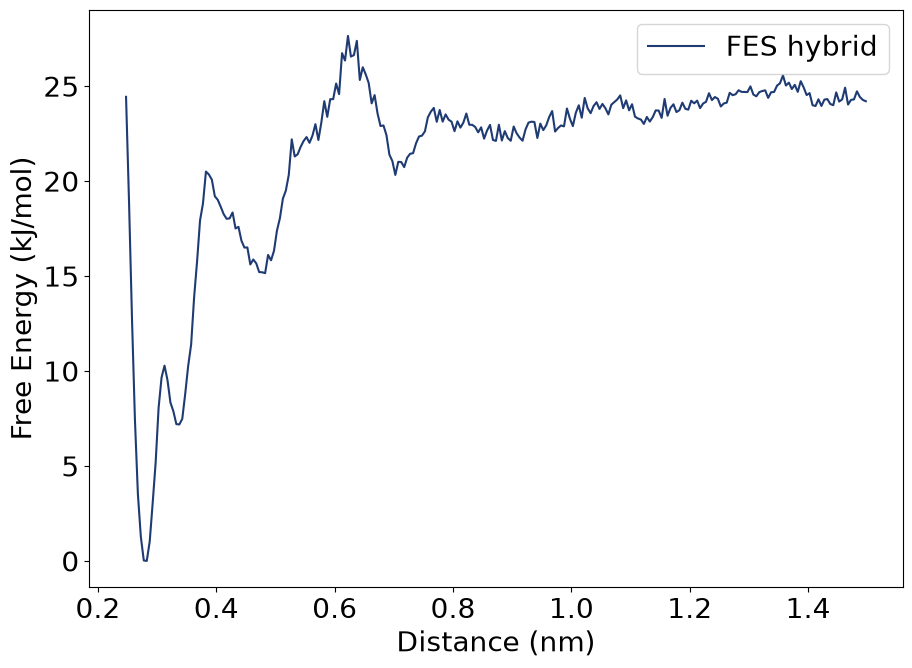

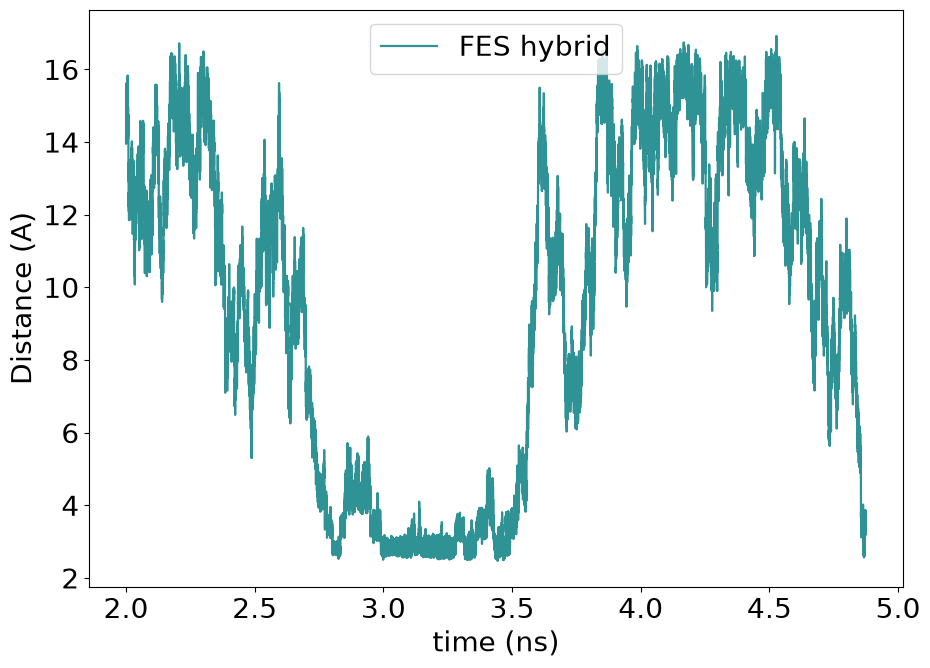

In [7]:
Nignore=40000

df = pd.read_csv('./COLVAR', sep='\s+', names=range(11), comment='#')
colvar = df.to_numpy()

cv=colvar[Nignore:,1] #variable colectiva, distancia
time=colvar[Nignore:,0]
bias=colvar[Nignore:,2]+colvar[Nignore:,7]

time[57492-Nignore:]+=time[57491-Nignore]+0.05
cv1=10*cv[57492-Nignore:]
cv2=colvar[57492:,10]

kb=0.00831446261
temp=330
beta=1/(kb*temp)
logweights=beta*bias
logweights_1=beta*bias[57492-Nignore:]
logweights -= np.amax(logweights)
histo, bins = np.histogram(cv,weights=np.exp(logweights),range=(0,1.5),bins=binNumber) #probabilidad en función de la distancia
ctr_bins_bias=(bins[1:]+bins[:-1])/2 
factor=4*np.pi*np.power(ctr_bins_bias,2)
fes_bias=-(1/beta)*np.log(histo)
fes_bias -= np.amin(fes_bias)
fes_renorm = -(1/beta)*np.log(histo/factor)
condition=np.logical_and(ctr_bins_bias>0.6,ctr_bins_bias<0.9)
#baseline=np.mean(fes_renorm[condition])
#fes_renorm -= baseline
fes_renorm -= np.amin(fes_renorm)

plt.figure()
plt.plot(ctr_bins_bias,fes_bias, color=paletteFessa[0], label='FES hybrid')
plt.xlabel('Distance (nm)')
plt.ylabel('Free Energy (kJ/mol)')
plt.legend()
plt.show()

plt.figure()
plt.plot(time/1000, cv*10, color=paletteFessa[1], label='FES hybrid', linewidth=1.6)
plt.xlabel('time (ns)')
plt.ylabel('Distance (A)')
plt.legend()
plt.show()


/tmp/ipykernel_4014138/964698391.py:13: RuntimeWarning: divide by zero encountered in log
  fes = -(1/beta)*np.log(Z)


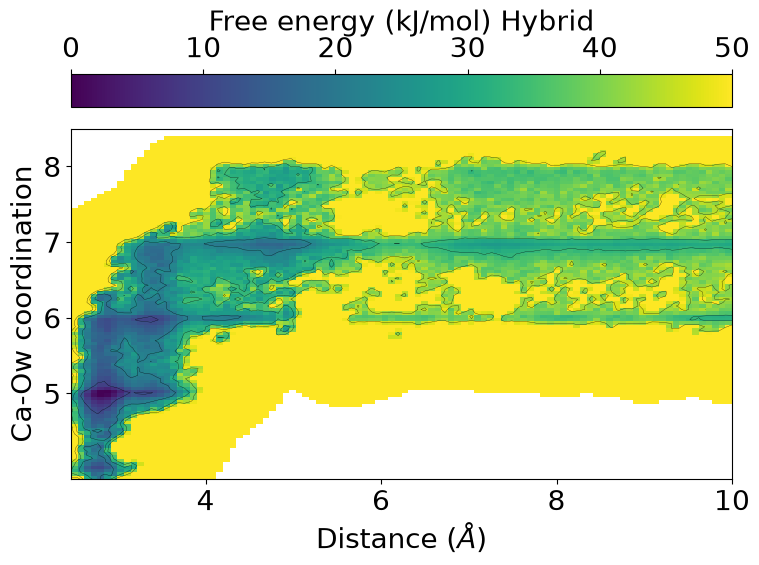

In [11]:
xmin=np.amin(cv1)
xmax=10. 
ymin=np.amin(cv2)
ymax=np.amax(cv2)
X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([cv1, cv2])

kernel = stats.gaussian_kde(values, weights=np.exp(logweights_1), bw_method=0.07)
Z = np.reshape(kernel(positions).T, X.shape)


fes = -(1/beta)*np.log(Z)
fes -= np.amin(fes)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

im = ax.imshow(np.rot90(fes), extent=[xmin, xmax, ymin, ymax], vmin=0, vmax=50, aspect='auto')

cbar = fig.colorbar(im, orientation="horizontal", ax=ax, location='top')
cs = ax.contour(X, Y, fes, levels=np.linspace(0,44,5), colors='k', vmin=0, vmax=50, linewidths=0.2)

cbar.set_label('Free energy (kJ/mol) Hybrid')

ax.set_xlim([xmin, xmax])
ax.set_ylim([np.amin(cv2), 8.5])
ax.set_yticks([5, 6, 7, 8])

ax.set_xlabel(r"Distance ($\AA$)")
ax.set_ylabel(r"Ca-Ow coordination")

plt.tight_layout() # Para que ajuste los márgenes automáticamente y no se corte nada
plt.show()


SCAN-ML-LARGE

In [18]:
#Datos pablo large
numSim=4
Nignore=1000
fes_all_large=np.zeros([numSim,binNumber])
fes_all_renorm_large=np.zeros([numSim,binNumber])
for i in range(numSim):
    colvar=np.genfromtxt("/scratch/vperez/ForVera/CaCO3-SCAN-ML/molecular-dynamics/ion-pairing/caco3-batches-large/" + str(i+1) + "/COLVAR")
    cv=colvar[Nignore:,1]
    time=colvar[Nignore:,0]
    bias=colvar[Nignore:,2]+colvar[Nignore:,7]
    kb=0.00831446261
    temp=330
    beta=1/(kb*temp)
    logweights=beta*bias
    logweights -= np.amax(logweights)
    histo, bins = np.histogram(cv,weights=np.exp(logweights),range=(0,2.0),bins=binNumber)
    ctr_bins_large=(bins[1:]+bins[:-1])/2
    factor=4*np.pi*np.power(ctr_bins_large,2)
    fes=-(1/beta)*np.log(histo)
    fes -= np.amin(fes)
    fes_renorm = -(1/beta)*np.log(histo/factor)
    #condition=np.logical_and(ctr_bins_large>0.8,ctr_bins_large<1.4)
    #baseline=np.mean(fes_renorm[condition])
    #fes_renorm -= baseline
    fes_renorm -= np.amin(fes_renorm)
    fes_all_large[i,:] = fes
    fes_all_renorm_large[i,:] = fes_renorm

/tmp/ipykernel_1355616/3867154795.py:19: RuntimeWarning: divide by zero encountered in log
  fes=-(1/beta)*np.log(histo)
/tmp/ipykernel_1355616/3867154795.py:21: RuntimeWarning: divide by zero encountered in log
  fes_renorm = -(1/beta)*np.log(histo/factor)


SCAN-ML-EXTRA-LARGE

In [19]:
#Voy a ver cómo importo los datos del modelo estudiado por pablo de SCAN-ML
numSim=4
Nignore=1000
fes_all_xlarge=np.zeros([numSim,binNumber])
fes_all_renorm_xlarge=np.zeros([numSim,binNumber])

plt.figure()
for i in range(numSim):
    colvar=np.genfromtxt("/scratch/vperez/ForVera/CaCO3-SCAN-ML/molecular-dynamics/ion-pairing/caco3-batches-extra-large/" + str(i+1) + "/COLVAR")
    cv=colvar[Nignore:,1]
    time=colvar[Nignore:,0]
    bias=colvar[Nignore:,2]+colvar[Nignore:,7]
    kb=0.00831446261
    temp=330
    beta=1/(kb*temp)
    logweights=beta*bias
    logweights -= np.amax(logweights)
    histo, bins = np.histogram(cv,weights=np.exp(logweights),range=(0,2.1),bins=binNumber)
    ctr_bins_xlarge=(bins[1:]+bins[:-1])/2
    factor=4*np.pi*np.power(ctr_bins_large,2)
    fes=-(1/beta)*np.log(histo)
    fes -= np.amin(fes)
    fes_renorm = -(1/beta)*np.log(histo/factor)
    #condition=np.logical_and(ctr_bins_large>0.8,ctr_bins_large<1.4)
    #baseline=np.mean(fes_renorm[condition])
    #fes_renorm -= baseline
    fes_renorm -= np.amin(fes_renorm)
    fes_all_xlarge[i,:] = fes
    fes_all_renorm_xlarge[i,:] = fes_renorm

    # plt.plot(time/1000, cv*10, color=paletteFessa[i], label='Simulation ' + str(i+1), linewidth=1.6)
    # plt.xlabel('time (ns)')
    # plt.ylabel('Distance (A)')
    # plt.legend()
    # plt.show()





/tmp/ipykernel_1355616/3168780820.py:21: RuntimeWarning: divide by zero encountered in log
  fes=-(1/beta)*np.log(histo)
/tmp/ipykernel_1355616/3168780820.py:23: RuntimeWarning: divide by zero encountered in log
  fes_renorm = -(1/beta)*np.log(histo/factor)


<Figure size 1050x750 with 0 Axes>

In [20]:
#ax[1].plot(10*ctr_bins,np.mean(fes_all_renorm,axis=0),linewidth=3)
f = interpolate.interp1d(10*ctr_bins_xlarge,np.mean(fes_all_xlarge,axis=0))
x = np.linspace(np.amin(10*ctr_bins_xlarge),np.amax(10*ctr_bins_xlarge),10000)
#ax[1].scatter(x,f(x),c=f(x),vmin=0,vmax=30,s=2)
# plt.plot(x,f(x),label="SCAN-ML",color=paletteCaCO3[2],linewidth=1.25,zorder=2)
# plt.xlabel('Distance (A)')
# plt.ylabel('Free Energy (kJ/mol)')
# plt.legend()
# plt.show()

COMAPRAMOS CON ESTOS DATOS Y CON LA LITERATURA

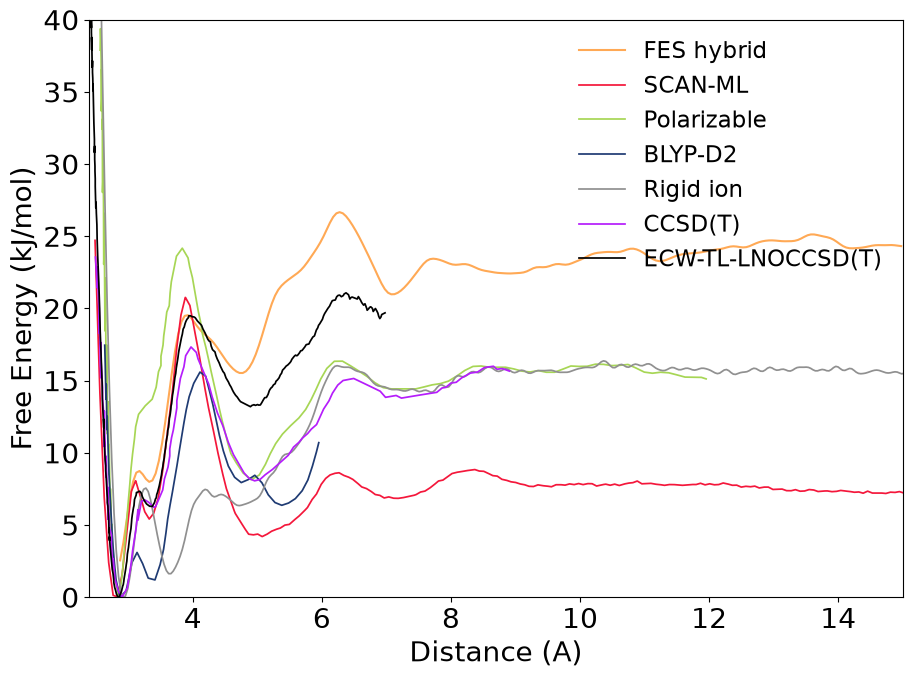

In [21]:
plt.figure()

fes_bias_smooth = gaussian_filter1d(fes_bias, sigma=2) #para suavizar un poco la curva
plt.plot(ctr_bins_bias*10,fes_bias_smooth, color=paletteCaCO3[4], label='FES hybrid', linewidth=1.5)
plt.plot(x,f(x),label="SCAN-ML",color=paletteCaCO3[2],linewidth=1.25)

xmin=np.amin(cv)*10

data=np.genfromtxt("/scratch/vperez/ForVera/CaCO3-SCAN-ML/notebooks/literature-data/ion-pairing/ion-pairing-amoeba.txt")
#factor=4*np.pi*np.power(data[:,0]/10,2)
fes=data[:,1]#+(1/beta)*np.log(factor)
fes -= np.amin(fes)
plt.plot(data[:,0],fes,label="Polarizable",color=paletteCaCO3[0],linewidth=1.25)
data=np.genfromtxt("/scratch/vperez/ForVera/CaCO3-SCAN-ML/notebooks/literature-data/ion-pairing/ion-pairing-blyp-d2.txt")
plt.plot(data[:,0],4.184*(data[:,1]-np.amin(data[:,1])),label="BLYP-D2",color=paletteFessa[0],linewidth=1.25)
#data=np.genfromtxt("ion-pairing-rigid-ion.txt")
data=np.genfromtxt("/scratch/vperez/ForVera/CaCO3-SCAN-ML/notebooks/literature-data/ion-pairing/ion-pairing-rigid-ion-new.txt")
#factor=4*np.pi*np.power(data[:,0],2)
fes=data[:,1] #+(1/beta)*np.log(factor)
fes -= np.amin(fes)
plt.plot(10*data[:,0],fes,label="Rigid ion",color=paletteCaCO3[1],linewidth=1.25)

data=np.genfromtxt("/scratch/vperez/ForVera/ExampleTrainDeePMD_Jax_2/literature/ccsd.txt")
#factor=4*np.pi*np.power(data[:,0]/10,2)
#ordenamos los datos de la matriz 
indices_ordenados = np.argsort(data[:, 0])
data = data[indices_ordenados]

factor=4*np.pi*np.power(data[:,0]/10,2)
fes=data[:,1]+(1/beta)*np.log(factor) #

fes -= np.amin(fes)
plt.plot(data[:,0],fes,label="CCSD(T)",color=paletteCaCO3[5],linewidth=1.25)


data=np.genfromtxt("/scratch/vperez/ForVera/ExampleTrainDeePMD_Jax_2/literature/ecw-tl.txt")


indices_ordenados = np.argsort(data[:, 0])
data = data[indices_ordenados]
factor=4*np.pi*np.power(data[:,0]/10,2)
fes=data[:,1]*4.184-2*(1/beta)*np.log(factor)
fes -= np.amin(fes)
plt.plot(data[:,0],fes,label="ECW-TL-LNOCCSD(T)",color='black',linewidth=1.25)



plt.xlabel('Distance (A)')
plt.ylabel('Free Energy (kJ/mol)')
plt.xlim([xmin,15.0])
plt.ylim([0,40])
plt.legend(
    loc='upper right',      # o 'best', 'upper left', 'lower right', etc.
    fontsize='small',
    frameon=False,
    ncol=1
)
plt.show()

El valor de Delta G (sumatorio) es: -21.44
69.779079984207
El valor de Delta G (integral) es: -21.44 kJ/mol
El valor de Delta G (integral) con electrostática es: -27.37 kJ/mol


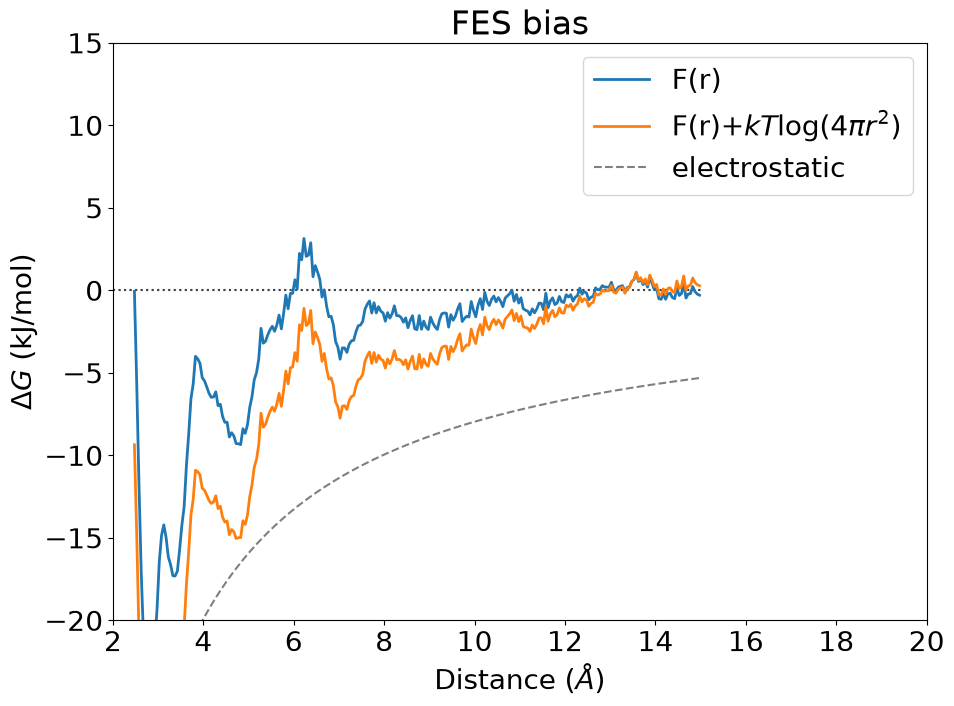

In [13]:
Nignore=40000

df = pd.read_csv('./COLVAR', sep='\s+', names=range(11), comment='#')
colvar = df.to_numpy()

cv=colvar[Nignore:,1] #variable colectiva, distancia
time=colvar[Nignore:,0]
bias=colvar[Nignore:,2]+colvar[Nignore:,7]

time[57492-Nignore:]+=time[57491-Nignore]+0.05

kb=0.00831446261
temp=330
beta=1/(kb*temp)
logweights=beta*bias
eps0=5.727*1.e-4 # e^2 / (kJ/mol angstrom)
eps=78
#logweights -= np.amax(logweights)

limit1 = 1.2
limit2 = 1.5


histo, bins = np.histogram(cv,weights=np.exp(logweights),range=(0,1.5),bins=binNumber)
ctr_bins=(bins[1:]+bins[:-1])/2
factor=4*np.pi*np.power(ctr_bins,2)

mask = histo > 0
histo = histo[mask]
ctr_bins = ctr_bins[mask]
factor = factor[mask]

fes=-(1/beta)*np.log(histo)
fes -= np.amin(fes)
fes_renorm =-(1/beta)*np.log(histo/factor)


condition= np.logical_and(ctr_bins>limit1,ctr_bins<limit2)
fes_renorm -=np.mean(fes_renorm[condition])
fes -=np.mean(fes[condition])


######## CALCULOS DELTA G

#calculo deltaG mediante suma

condition1=cv < limit1
condition2=np.logical_and(cv >= limit1, cv <= limit2)
deltaG = -(1/beta) * np.log((np.sum(np.exp(logweights[condition1]))*(4/3) * np.pi * (limit2**3 - limit1**3))/ (np.sum(np.exp(logweights[condition2]))*1.660))#-4/ (4 * np.pi * eps0 * eps * (limit1 + limit2) / 2.0) 
# print('logweights condicion 1: ', logweights[condition1])
# print('logweights condicion 2: ', logweights[condition2])
# print(f"Numerador: {np.sum(np.exp(logweights[condition1]))} Denominador: {np.sum(np.exp(logweights[condition2]))}")
print(f"El valor de Delta G (sumatorio) es: {deltaG:.2f}")


###############

plt.plot(10*ctr_bins,fes,linewidth=2.,label="F(r)")
plt.plot(10*ctr_bins,fes_renorm,linewidth=2.,label="F(r)+$kT\log(4 \pi r^2)$")
plt.plot([2,15],[0,0],':',zorder=0,color="black",alpha=0.5)


### busco la constante eps adecuada para mi modelo

condition4= np.logical_and(ctr_bins > 1.2, ctr_bins < limit2)
def electrostatica(x,k, C):
    return -(4/(4*np.pi*eps0*k*x))+C

p_optimos, p_covarianza = curve_fit(electrostatica, ctr_bins[condition4], fes_renorm[condition4])

eps=p_optimos[0]
C=p_optimos[1]
print(eps)

############# DELTA G MEDIANTE INTEGRAL 

C0=1/1.660 #nm^-3
shift=0
fes_renorm -= shift
condition=ctr_bins<limit1
kb=0.00831446261
temp=330
beta=1/(kb*temp)
integral=trapezoid(np.exp(-beta*fes_renorm[condition])*4*np.pi*np.power(ctr_bins[condition],2),x=ctr_bins[condition])
delta_G=-kb*temp*np.log(C0*integral)
print(f"El valor de Delta G (integral) es: {delta_G:.2f} kJ/mol")

shift=C
fes_renorm -= shift
integral=trapezoid(np.exp(-beta*fes_renorm[condition])*4*np.pi*np.power(ctr_bins[condition],2),x=ctr_bins[condition])
delta_G=-kb*temp*np.log(C0*integral)
print(f"El valor de Delta G (integral) con electrostática es: {delta_G:.2f} kJ/mol")

########################


electrostatic = -(4/(4*np.pi*eps0*eps*ctr_bins))
plt.plot(10*ctr_bins,electrostatic,'--',zorder=0,color="black",alpha=0.5,label="electrostatic")
plt.plot([2,15],[0,0],':',zorder=0,color="black",alpha=0.5)

# index_val= np.where(condition)[0]
# index_rel = np.argmax(fes_renorm[condition])
# index = index_val[index_rel]
# shift=fes_renorm[index]-electrostatic[index]
# print(shift)

plt.ylim([-20,15])
plt.xlim([2,20])

plt.legend()

plt.xlabel("Distance ($\AA$)")
plt.ylabel("$\Delta G$ (kJ/mol)")
plt.title("FES bias")
plt.show()


